In [7]:
import sys

from pathlib import Path
root = Path.cwd()
while not (root / "Models").is_dir():
    root = root.parent
sys.path.insert(0, str(root))

from config import *

from Models.Papers.Xu2023 import Xu2023

In [8]:
importlib.reload(Xu2023)

Xu2023.Table2().df

,redshift,model,log10M0,alpha,delta,beta,log10k_log10eps,sigma
0,zs<0.2,BP13,11.338,0.484,3.041,1.632,-1.545,0.237
1,0.2<zs<0.4,BP13,11.359,0.623,3.248,1.702,-1.598,0.190
2,0.5<zs<0.7,BP13,11.509,0.740,2.964,2.094,-1.565,0.190
3,zs<0.2,DP,11.732,0.299,NaN,1.917,10.303,0.233
4,0.2<zs<0.4,DP,11.579,0.429,NaN,2.215,10.105,0.201
5,0.5<zs<0.7,DP,11.624,0.466,NaN,2.513,10.133,0.192


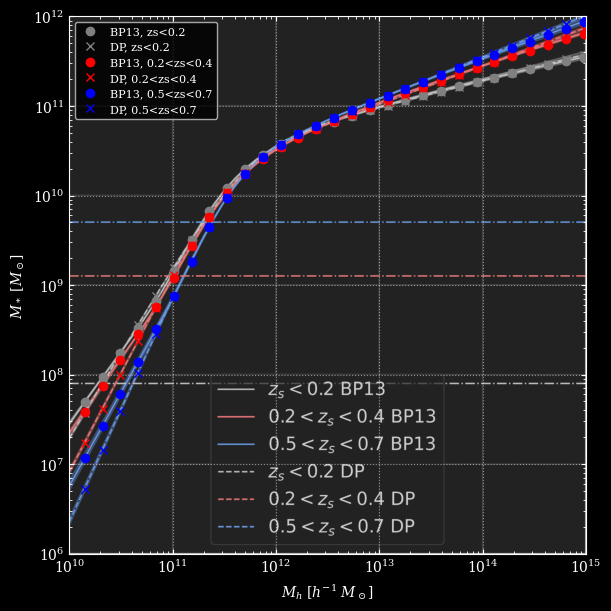

In [9]:
importlib.reload(Xu2023)

fig, axs = Xu2023.Fig7().full()

logMh = np.linspace(10, 15, 30)  # log10(Mh), same convention SHMR() expects
Mh_plot = 10**logMh / Xu2023.Cosmology.h  # matches Fig7's h^-1 Msun x-axis (see Models/SHMRsCheck.ipynb)

colors = {'zs<0.2': 'gray', '0.2<zs<0.4': 'red', '0.5<zs<0.7': 'blue'}
markers = {'BP13': 'o', 'DP': 'x'}

for redshift, color in colors.items():
    for model, marker in markers.items():
        shmr = Xu2023.SHMR(model=model, redshift=redshift, logMh=logMh)
        logMstar = shmr.log10Mstar_BP13() if model == 'BP13' else shmr.log10Mstar_DP()
        axs.plot(Mh_plot, 10**logMstar, marker=marker, ls='None', color=color, label=f'{model}, {redshift}')

axs.legend(fontsize=8)

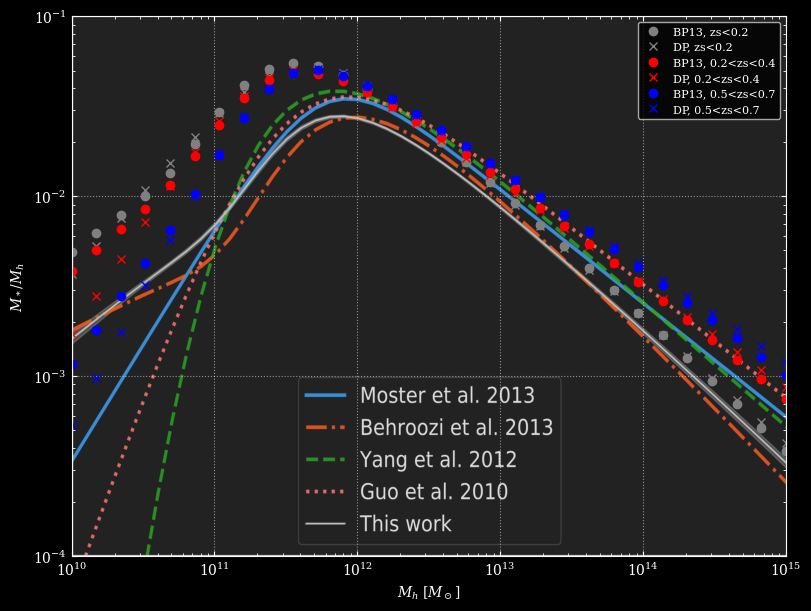

In [11]:
importlib.reload(Xu2023)

fig, axs = Xu2023.Fig9().full()

logMh = np.linspace(10, 15, 30)  # log10(Mh), same convention SHMR() expects
Mh_plot = 10**logMh

colors = {'zs<0.2': 'gray', '0.2<zs<0.4': 'red', '0.5<zs<0.7': 'blue'}
markers = {'BP13': 'o', 'DP': 'x'}

for redshift, color in colors.items():
    for model, marker in markers.items():
        shmr = Xu2023.SHMR(model=model, redshift=redshift, logMh=logMh)
        logMstar = shmr.log10Mstar_BP13() if model == 'BP13' else shmr.log10Mstar_DP()
        axs.plot(Mh_plot, 10**logMstar/Mh_plot, marker=marker, ls='None', color=color, label=f'{model}, {redshift}')

axs.legend(fontsize=8)

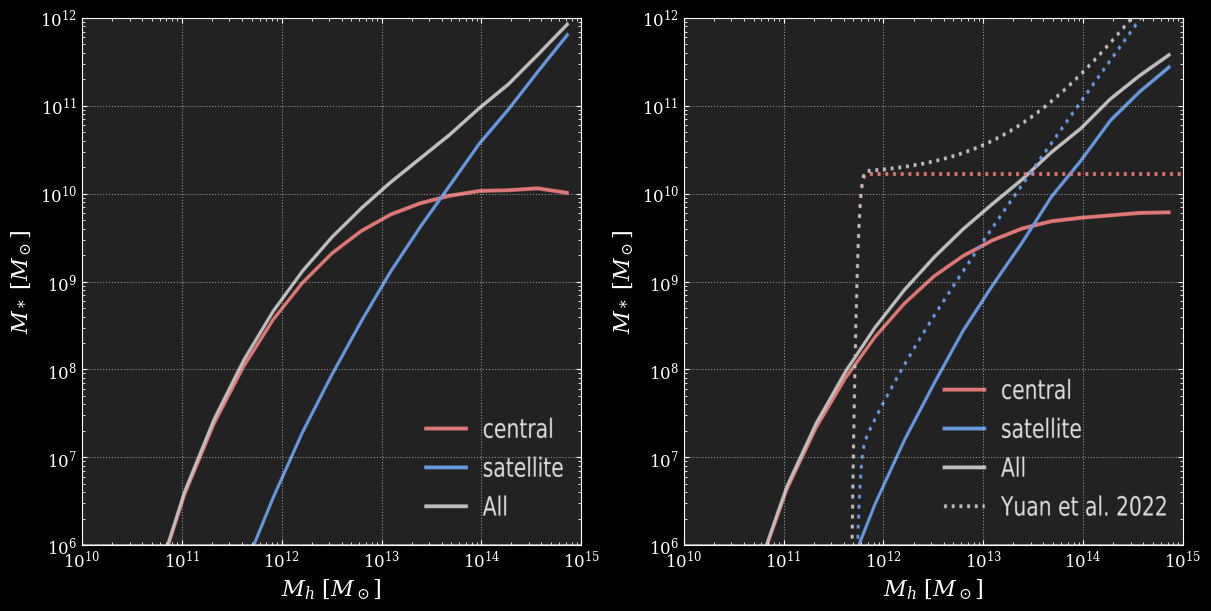

In [5]:
importlib.reload(Xu2023)

fig, axs = Xu2023.Fig13().full()